In [2]:
import os
import re
import datetime
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.colors import LinearSegmentedColormap
from matplotlib.gridspec import GridSpec
from scipy import stats
from scipy.ndimage import gaussian_filter1d

%cd "C:\Users\jasmineyeo\Documents\GitHub\V1_SpatialModulation"
from helper import TwoP, read_xml, time2float
from helper import SpikeSmoothing, BehavioralDataFiltering as DF, spatial_discretization as SD, ReliabilityTesting as RT, ResponseVisualization as RV, SpatialModulationIndex as SMI
from helper.SpatialModulationIndexLayerSpecific import SpatialModulationIndexLayerSpecific as SMI_Layer
from helper.detrendAdaptation import detrendAdaptation as DA

from matplotlib import rcParams
rcParams['legend.fontsize'] = 14
rcParams['axes.labelsize'] = 14
rcParams['axes.titlesize'] = 20
rcParams['xtick.labelsize'] = 14
rcParams['ytick.labelsize'] = 14

C:\Users\jasmineyeo\Documents\GitHub\V1_SpatialModulation


=== THREE-SESSION SMI ANALYSIS (Layer 2/3) ===

Analyzing spatial modulation index across three recording sessions
Note: Independent samples analysis (different cell populations per session)

=== DESCRIPTIVE STATISTICS ===

Session Statistics:
   session    n    mean     sem  median     std     min     max     q25  \
0        1  129  0.3258  0.0295  0.3741  0.3335 -0.9936  0.9988  0.1573   
1        2  141  0.3257  0.0276  0.3324  0.3269 -1.0000  0.9950  0.1703   
2        3  138  0.3858  0.0234  0.4161  0.2733 -0.7412  0.9883  0.2418   

      q75  
0  0.5472  
1  0.5329  
2  0.5426  

=== ONE-WAY ANOVA ===

F(2, 405) = 1.679
p-value = 0.1879
η² (eta-squared) = 0.008
No significant overall difference between sessions
Individual comparisons may still be informative...

=== PAIRWISE COMPARISONS ===

Session 2 vs Session 1 (n₁=129, n₂=141):
  Mean difference: -0.0002
  t = -0.005, p = 0.9963
  Bonferroni corrected p = 1.0000
  Effect size (Cohen's d): -0.001 (negligible)
  No significant

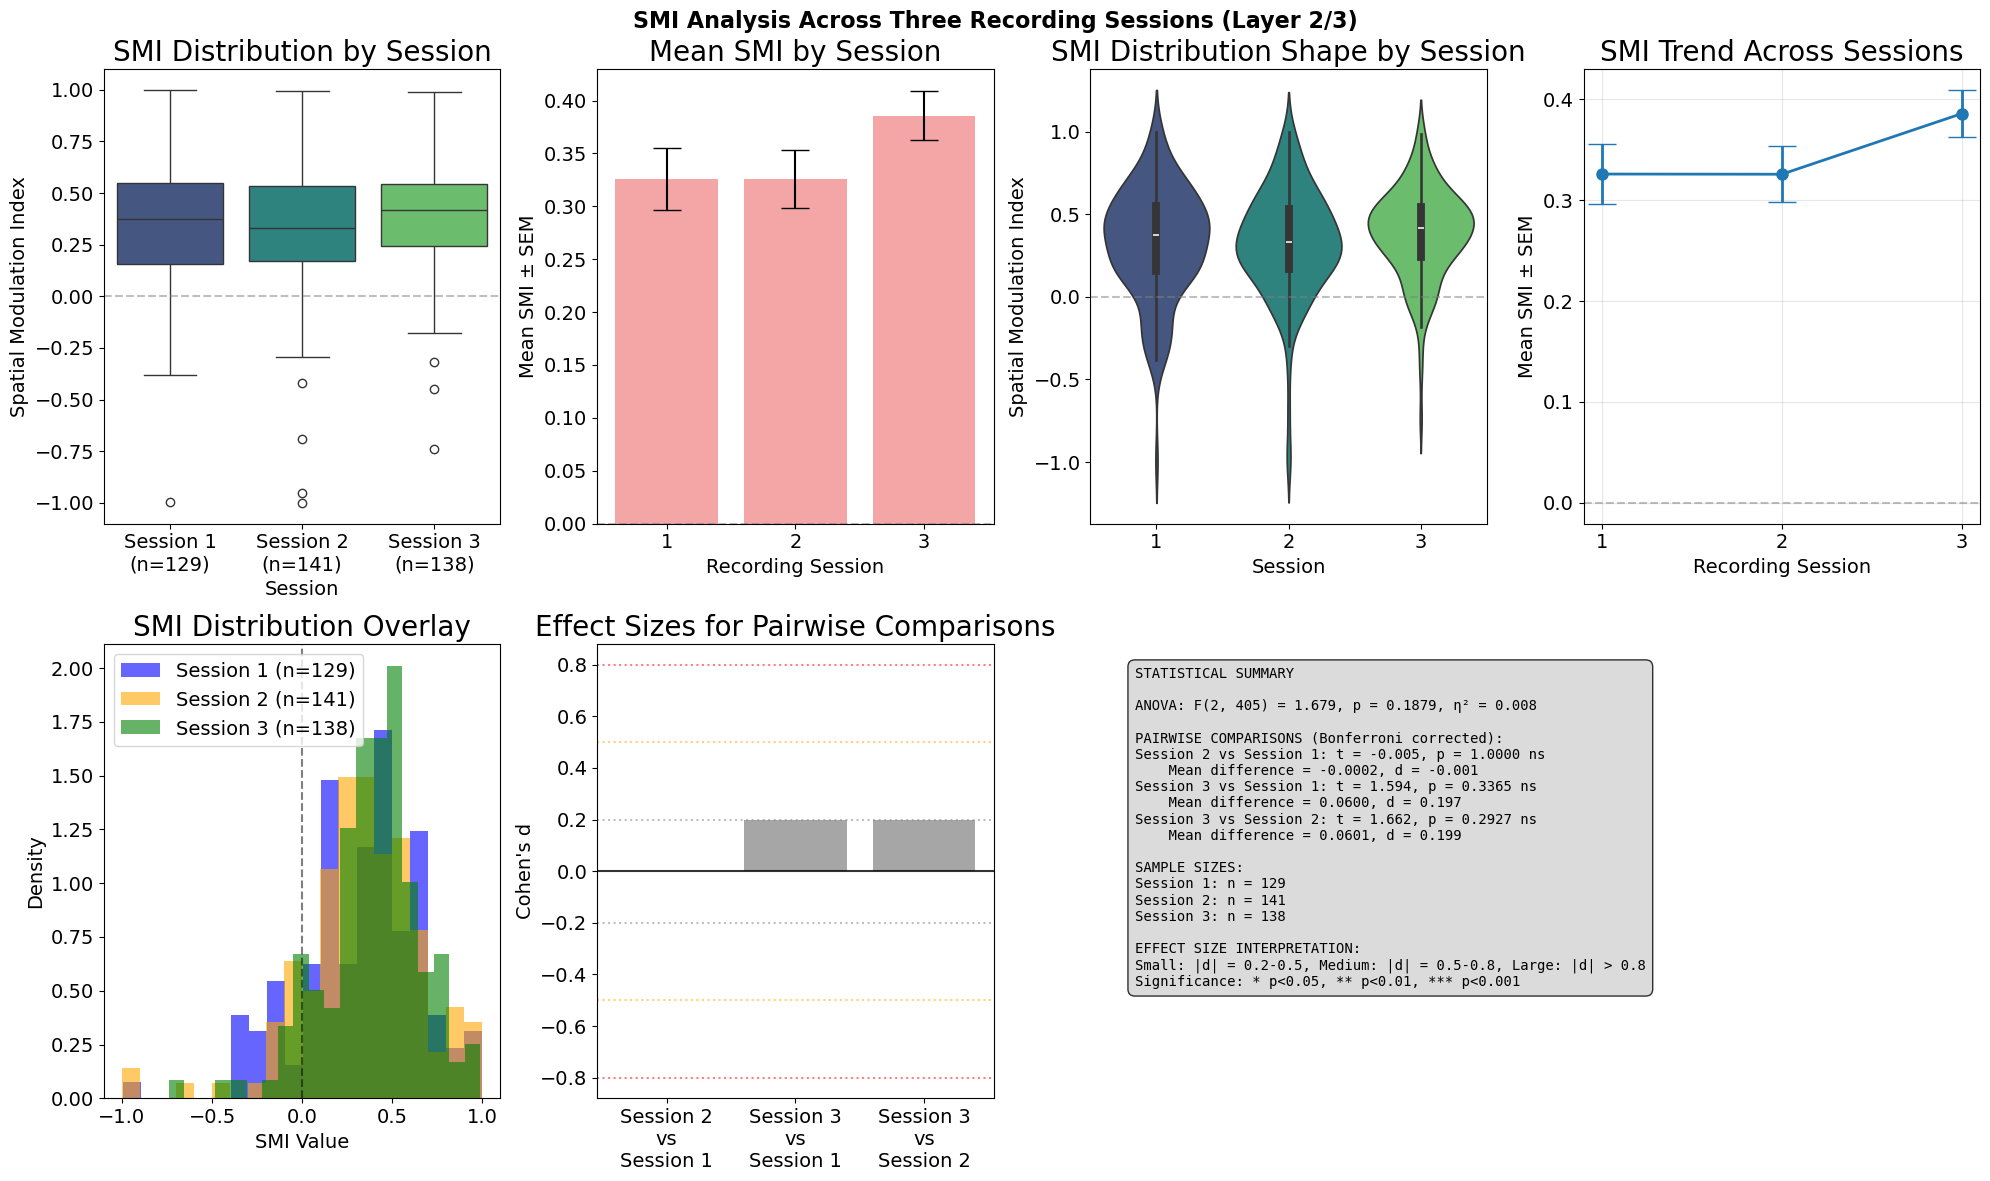


=== SUMMARY INTERPRETATION ===

Analysis of SMI differences across three recording sessions (Layer 2/3):
(Independent samples analysis - different cell populations per session)

✗ ANOVA indicates no significant overall differences between sessions (p = 0.1879)

Pairwise comparisons (with Bonferroni correction):
• Session 2 vs Session 1: No significant difference (p = 1.0000)
• Session 3 vs Session 1: No significant difference (p = 0.3365)
• Session 3 vs Session 2: No significant difference (p = 0.2927)

Session means (± SEM):
• Session 1: 0.3258 ± 0.0295 (n = 129)
• Session 2: 0.3257 ± 0.0276 (n = 141)
• Session 3: 0.3858 ± 0.0234 (n = 138)

=== ANALYSIS COMPLETE ===
Script completed successfully. All statistical comparisons and visualizations generated.


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec
from scipy import stats
from scipy.stats import ttest_rel, ttest_ind, f_oneway
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import warnings
warnings.filterwarnings('ignore')

# Layer 2/3 SMI data from three recording sessions
# Day 1 data
day1_l23 = np.array([[ 0.44739231,  0.85636828,  0.99878637, -0.23913901,  0.66910044,  0.56374865,
    0.99658105,  0.45598884,  0.68574722, -0.37712048,  0.18087869,  0.45710596,
    0.15727775,  0.83689569, -0.38142928, -0.15524595,  0.35843612,  0.69105987,
 -0.99357842, -0.1935702,   0.01045711, -0.14768168,  0.09333947,  0.4342266,
    0.33630991,  0.43091525,  0.44871119,  0.12524901,  0.12567755, -0.27191913,
 -0.32001613,  0.48122624, -0.27268214,  0.32807249,  0.0982323,   0.49750133,
    0.64717887,  0.74735928, -0.10770211,  0.9614859,   0.75122329,  0.19572782,
    0.62720813,  0.48559836,  0.72284005,  0.44742075,  0.0016989,   0.20354229,
    0.10131144,  0.25131461,  0.19287156,  0.16704232,  0.65478383,  0.60175174,
    0.19425945,  0.83033782,  0.44216965,  0.10204444,  0.18356964,  0.65068594,
    0.45726442,  0.36344987,  0.32504758,  0.49140895,  0.45385398,  0.14862763,
    0.66644095, -0.3779569,  -0.28153554, -0.07890916, -0.32090841,  0.32645444,
    0.59152944,  0.419745,    0.66265525,  0.30185512,  0.41050511,  0.1969272,
 -0.14995352,  0.07319122,  0.76649813,  0.44415368,  0.50628881,  0.52055488,
    0.27914184,  0.53303758,  0.20049217,  0.33837994,  0.4427333,   0.65213599,
    0.3886069,   0.56648351,  0.14878212,  0.54588218, -0.17914001,  0.40037769,
    0.6083969,   0.17839392,  0.17743248,  0.55054503,  0.26834741,  0.92706828,
    0.16011914,  0.77670461,  0.63536408,  0.54721518,  0.47470797,  0.37715185,
    0.68617286,  0.54335412,  0.41294067,  0.13380292,  0.34824476,  0.22175859,
    0.41376635,  0.17507217,  0.25845341,  0.66122814,  0.30649756,  0.03145007,
    0.22148973, -0.13679351,  0.3912951,   0.19804735,  0.07654215,  0.37411779,
    0.26080024,  0.44027467,  0.63084696]])

# Day 2 data
day2_l23 = np.array([0.69531708, 0.51812711, -0.95251042, 0.98309866, 0.9536364, 0.80496855,
    0.07256877, 0.68679976, 0.33235161, 0.99503258, 0.5765939, 0.81483435,
    0.85950794, 0.17028003, 0.49951603, -0.04768599, 0.23499572, 0.40573624,
    0.36509887, 0.4418985, -1., 0.24004339, 0.81356559, 0.35737737,
    0.27589885, 0.05310801, 0.05683661, 0.36821451, 0.06959369, 0.59045607,
    0.58185711, 0.17096626, 0.20167074, 0.42543113, 0.53291286, 0.43124373,
    0.93352933, 0.31302227, -0.02340007, -0.04206219, 0.59417667, 0.23483911,
    0.6556506, 0.22067848, 0.71062145, 0.53502334, 0.91171641, 0.06684978,
    0.39396021, 0.11475789, 0.40635024, 0.23245604, -0.4202313, 0.29780702,
    0.20336025, 0.273029, 0.4226405, 0.23694627, -0.03357311, 0.38831937,
    0.31614255, 0.28678686, -0.29627606, 0.1446324, 0.14308262, -0.0219905,
    0.56691402, -0.02253608, 0.80947445, 0.43147963, 0.22310057, 0.51642117,
    -0.69191245, 0.69001388, 0.52684231, -0.13203152, 0.59318186, 0.11348351,
    0.02573415, 0.49445489, 0.55362084, 0.55514772, 0.48819313, 0.30591832,
    0.33374394, 0.44463378, 0.62249324, -0.04752905, 0.29962549, 0.18662727,
    0.41580993, -0.06109298, 0.5585034, 0.38283, 0.76399867, 0.31349451,
    0.26365977, -0.14289201, 0.25258142, 0.11966018, 0.50332375, 0.20942753,
    0.24679881, -0.14123333, 0.3757463, 0.63377953, 0.12062212, 0.3329127,
    0.4021988, 0.14865748, 0.18385541, 0.44472286, 0.27173157, 0.83232314,
    0.19465728, 0.1690905, 0.64034763, 0.35029898, 0.24567833, 0.43227121,
    -0.11716041, 0.42312955, -0.14271155, 0.75714462, 0.52759985, 0.21567399,
    0.16427047, 0.2016745, 0.62022916, 0.65578361, 0.30642737, -0.04257471,
    0.6100452, 0.23678437, 0.17618354, 0.3722822, 0.66719157, 0.35476317,
    0.49113526, 0.00119817, 0.30911065])

# Day 3 data
day3_l23 = np.array([0.3941641, 0.51480006, 0.61500347, 0.16243437, 0.38548021, 0.21755358,
    0.97658075, 0.65651675, 0.75261737, 0.14437755, 0.98830939, 0.7998832,
    0.77680683, 0.75011096, -0.31836973, 0.97994644, 0.86181728, 0.53058446,
    0.85800932, 0.36811023, 0.44033548, 0.46088942, 0.52086758, 0.79867764,
    0.53438939, 0.35554611, 0.36451338, 0.1694668, 0.12193764, 0.33463301,
    0.0624478, 0.3746058, 0.29940212, 0.73844388, 0.51588763, 0.17775553,
    0.36956496, 0.54011191, -0.06421538, 0.44261453, 0.03653188, 0.38067446,
    0.27858255, 0.37598133, 0.24186205, 0.48873415, 0.78283617, 0.00507223,
    0.62578604, 0.64709919, 0.08681246, -0.04595332, 0.39357684, 0.29617374,
    0.54309495, 0.59266762, -0.10784149, 0.23887828, 0.65674156, 0.35562386,
    0.54272216, 0.03343574, 0.44641065, 0.64855653, 0.04568425, 0.43247746,
    0.52537415, 0.70163398, 0.56585421, -0.45014658, 0.45944017, 0.35544999,
    0.33594083, 0.56057232, -0.17998169, 0.33855165, 0.22473017, 0.33120852,
    0.54231523, 0.15191607, 0.48875567, 0.05023956, 0.22452798, 0.60533198,
    0.23145789, -0.06018984, 0.25685375, 0.43849665, 0.25655828, 0.3883288,
    -0.04389578, 0.48874375, 0.53500133, 0.63634482, 0.29183671, 0.42257005,
    0.46967199, 0.50228079, 0.30036581, 0.41163629, 0.51707814, 0.21325348,
    0.59555486, -0.04927111, 0.30554798, 0.42100144, 0.52462686, 0.75874095,
    0.0279099, 0.41789475, 0.48350004, 0.55137638, 0.4143657, 0.24174422,
    0.49050017, 0.67136689, 0.59688687, 0.52216912, 0.29938177, 0.22935744,
    0.05242168, -0.74116434, 0.02102309, -0.08785607, 0.49593159, 0.28423658,
    0.32954483, 0.40009409, 0.48988935, 0.44424526, 0.32247527, 0.45477801,
    0.58908798, 0.69429111, 0.45889254, 0.31311872, 0.5673037, 0.56561317])

# Flatten the arrays since they're 2D with one row
day1_l23 = day1_l23.flatten()
day2_l23 = day2_l23.flatten()
day3_l23 = day3_l23.flatten()

def calculate_session_stats(data, session):
    """Calculate descriptive statistics for each recording session"""
    return {
        'session': session,
        'n': len(data),
        'mean': np.mean(data),
        'sem': stats.sem(data),
        'median': np.median(data),
        'std': np.std(data),
        'min': np.min(data),
        'max': np.max(data),
        'q25': np.percentile(data, 25),
        'q75': np.percentile(data, 75)
    }

def perform_pairwise_comparison(data1, data2, session1, session2):
    """Perform independent samples t-test between two sessions"""
    # Use Welch's t-test (unequal variances assumed)
    t_stat, p_value = ttest_ind(data2, data1, equal_var=False)
    
    # Calculate effect size (Cohen's d)
    n1, n2 = len(data1), len(data2)
    pooled_std = np.sqrt(((n1-1)*np.var(data1, ddof=1) + (n2-1)*np.var(data2, ddof=1)) / (n1+n2-2))
    effect_size = (np.mean(data2) - np.mean(data1)) / pooled_std
    
    return {
        'comparison': f'Session {session2} vs Session {session1}',
        't_stat': t_stat,
        'p_value': p_value,
        'effect_size': effect_size,
        'mean_change': np.mean(data2) - np.mean(data1),
        'session1': session1,
        'session2': session2,
        'n_session1': n1,
        'n_session2': n2
    }

def perform_anova_analysis(data_dict):
    """Perform one-way ANOVA across all three sessions"""
    data_values = list(data_dict.values())
    
    # Perform ANOVA
    f_stat, p_value = f_oneway(*data_values)
    
    # Calculate eta-squared (effect size for ANOVA)
    all_data = np.concatenate(data_values)
    grand_mean = np.mean(all_data)
    
    ss_between = sum([len(group) * (np.mean(group) - grand_mean)**2 for group in data_values])
    ss_total = sum([(x - grand_mean)**2 for x in all_data])
    eta_squared = ss_between / ss_total
    
    return {
        'f_stat': f_stat,
        'p_value': p_value,
        'eta_squared': eta_squared,
        'df_between': len(data_values) - 1,
        'df_within': len(all_data) - len(data_values)
    }

def create_long_format_dataframe():
    """Create a long-format dataframe for analysis and plotting"""
    data = []
    
    # Add data from all three sessions
    for val in day1_l23: data.append({'SMI': val, 'Session': 1})
    for val in day2_l23: data.append({'SMI': val, 'Session': 2})
    for val in day3_l23: data.append({'SMI': val, 'Session': 3})
    
    return pd.DataFrame(data)

def interpret_effect_size(d):
    """Interpret Cohen's d effect size"""
    abs_d = abs(d)
    if abs_d < 0.2:
        return "negligible"
    elif abs_d < 0.5:
        return "small"
    elif abs_d < 0.8:
        return "medium"
    else:
        return "large"

# Store data in dictionary for easier handling
session_data = {
    1: day1_l23,
    2: day2_l23,
    3: day3_l23
}

print("=== THREE-SESSION SMI ANALYSIS (Layer 2/3) ===\n")
print("Analyzing spatial modulation index across three recording sessions")
print("Note: Independent samples analysis (different cell populations per session)\n")

# Calculate descriptive statistics for each session
print("=== DESCRIPTIVE STATISTICS ===\n")
session_stats = []
for session, data in session_data.items():
    stats_dict = calculate_session_stats(data, session)
    session_stats.append(stats_dict)

stats_df = pd.DataFrame(session_stats)
print("Session Statistics:")
print(stats_df.round(4))

# Perform ANOVA to test overall differences
print("\n=== ONE-WAY ANOVA ===\n")
anova_result = perform_anova_analysis(session_data)
print(f"F({anova_result['df_between']}, {anova_result['df_within']}) = {anova_result['f_stat']:.3f}")
print(f"p-value = {anova_result['p_value']:.4f}")
print(f"η² (eta-squared) = {anova_result['eta_squared']:.3f}")

if anova_result['p_value'] < 0.05:
    print("**SIGNIFICANT OVERALL DIFFERENCE between sessions**")
    print("Proceeding with post-hoc pairwise comparisons...")
else:
    print("No significant overall difference between sessions")
    print("Individual comparisons may still be informative...")

# Perform all pairwise comparisons
print("\n=== PAIRWISE COMPARISONS ===\n")
pairwise_results = []
comparisons = [(1, 2), (1, 3), (2, 3)]

for session1, session2 in comparisons:
    result = perform_pairwise_comparison(session_data[session1], session_data[session2], session1, session2)
    pairwise_results.append(result)

# Apply multiple comparisons correction (Bonferroni)
p_values = [r['p_value'] for r in pairwise_results]
corrected_p = multipletests(p_values, method='bonferroni')[1]

for i, result in enumerate(pairwise_results):
    print(f"{result['comparison']} (n₁={result['n_session1']}, n₂={result['n_session2']}):")
    print(f"  Mean difference: {result['mean_change']:.4f}")
    print(f"  t = {result['t_stat']:.3f}, p = {result['p_value']:.4f}")
    print(f"  Bonferroni corrected p = {corrected_p[i]:.4f}")
    print(f"  Effect size (Cohen's d): {result['effect_size']:.3f} ({interpret_effect_size(result['effect_size'])})")
    
    # Interpret significance
    if corrected_p[i] < 0.05:
        direction = "higher" if result['mean_change'] > 0 else "lower"
        print(f"  **SIGNIFICANT: Session {result['session2']} SMI {direction.upper()} than Session {result['session1']}**")
    else:
        print("  No significant difference (after correction)")
    print()

# Create comprehensive visualization
fig = plt.figure(figsize=(20, 12))
gs = GridSpec(2, 4, figure=fig)
fig.suptitle('SMI Analysis Across Three Recording Sessions (Layer 2/3)', fontsize=16, fontweight='bold')

# Create dataframe for plotting
df = create_long_format_dataframe()

# Plot 1: Box plot across sessions
ax1 = fig.add_subplot(gs[0, 0])
sns.boxplot(data=df, x='Session', y='SMI', ax=ax1, palette='viridis')
ax1.set_title('SMI Distribution by Session')
ax1.set_ylabel('Spatial Modulation Index')
ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.5)

# Add sample sizes to x-axis labels
session_ns = [len(session_data[i]) for i in range(1, 4)]
ax1.set_xticklabels([f'Session {i}\n(n={n})' for i, n in enumerate(session_ns, 1)])

# Plot 2: Bar plot with means and error bars
ax2 = fig.add_subplot(gs[0, 1])
sessions = list(session_data.keys())
means = [np.mean(session_data[s]) for s in sessions]
sems = [stats.sem(session_data[s]) for s in sessions]

bars = ax2.bar(sessions, means, yerr=sems, capsize=10, alpha=0.7, color='lightcoral')
ax2.set_xlabel('Recording Session')
ax2.set_ylabel('Mean SMI ± SEM')
ax2.set_title('Mean SMI by Session')
ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax2.set_xticks(sessions)

# Add significance indicators for pairwise comparisons
max_height = max([m + s for m, s in zip(means, sems)])
y_offset = max_height * 0.1

for i, result in enumerate(pairwise_results):
    if corrected_p[i] < 0.05:
        s1, s2 = result['session1'], result['session2']
        
        # Determine bar height for significance indicator
        bar_y = max_height + y_offset * (i + 1)
        
        # Draw significance bar
        ax2.plot([s1, s2], [bar_y, bar_y], 'k-', linewidth=2)
        ax2.plot([s1, s1], [bar_y, bar_y - y_offset*0.3], 'k-', linewidth=2)
        ax2.plot([s2, s2], [bar_y, bar_y - y_offset*0.3], 'k-', linewidth=2)
        
        # Add significance marker
        if corrected_p[i] < 0.001:
            sig_text = '***'
        elif corrected_p[i] < 0.01:
            sig_text = '**'
        else:
            sig_text = '*'
        
        ax2.text((s1 + s2) / 2, bar_y + y_offset*0.1, sig_text, 
                ha='center', va='bottom', fontsize=12, fontweight='bold')

# Adjust y-axis to accommodate significance bars
if any(p < 0.05 for p in corrected_p):
    ax2.set_ylim(top=max_height + y_offset * (len(pairwise_results) + 1))

# Plot 3: Violin plot for distribution comparison
ax3 = fig.add_subplot(gs[0, 2])
sns.violinplot(data=df, x='Session', y='SMI', ax=ax3, palette='viridis')
ax3.set_title('SMI Distribution Shape by Session')
ax3.set_ylabel('Spatial Modulation Index')
ax3.axhline(y=0, color='gray', linestyle='--', alpha=0.5)

# Plot 4: Trend plot with confidence intervals
ax4 = fig.add_subplot(gs[0, 3])
ax4.errorbar(sessions, means, yerr=sems, marker='o', linewidth=2, markersize=8, capsize=10)
ax4.set_xlabel('Recording Session')
ax4.set_ylabel('Mean SMI ± SEM')
ax4.set_title('SMI Trend Across Sessions')
ax4.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax4.set_xticks(sessions)
ax4.grid(True, alpha=0.3)

# Plot 5: Histogram comparison
ax5 = fig.add_subplot(gs[1, 0])
colors = ['blue', 'orange', 'green']
for i, (session, data) in enumerate(session_data.items()):
    ax5.hist(data, bins=20, alpha=0.6, color=colors[i], 
             label=f'Session {session} (n={len(data)})', density=True)

ax5.axvline(0, color='k', linestyle='--', alpha=0.5)
ax5.set_title('SMI Distribution Overlay')
ax5.set_xlabel('SMI Value')
ax5.set_ylabel('Density')
ax5.legend()

# Plot 6: Pairwise comparison effect sizes
ax6 = fig.add_subplot(gs[1, 1])
comparison_labels = [r['comparison'] for r in pairwise_results]
effect_sizes = [r['effect_size'] for r in pairwise_results]
colors_effects = ['red' if abs(es) > 0.5 else 'orange' if abs(es) > 0.2 else 'gray' for es in effect_sizes]

bars = ax6.bar(range(len(effect_sizes)), effect_sizes, color=colors_effects, alpha=0.7)
ax6.set_xticks(range(len(comparison_labels)))
ax6.set_xticklabels([label.replace(' vs ', '\nvs\n') for label in comparison_labels], rotation=0, ha='center')
ax6.set_ylabel("Cohen's d")
ax6.set_title('Effect Sizes for Pairwise Comparisons')
ax6.axhline(y=0, color='black', linestyle='-', alpha=0.8)

# Add effect size reference lines
ax6.axhline(y=0.2, color='gray', linestyle=':', alpha=0.5, label='Small')
ax6.axhline(y=0.5, color='orange', linestyle=':', alpha=0.5, label='Medium')
ax6.axhline(y=0.8, color='red', linestyle=':', alpha=0.5, label='Large')
ax6.axhline(y=-0.2, color='gray', linestyle=':', alpha=0.5)
ax6.axhline(y=-0.5, color='orange', linestyle=':', alpha=0.5)
ax6.axhline(y=-0.8, color='red', linestyle=':', alpha=0.5)

# Plot 7: Statistical summary table as text
ax7 = fig.add_subplot(gs[1, 2:])
ax7.axis('off')

# Create summary text
summary_text = "STATISTICAL SUMMARY\n\n"
summary_text += f"ANOVA: F({anova_result['df_between']}, {anova_result['df_within']}) = {anova_result['f_stat']:.3f}, "
summary_text += f"p = {anova_result['p_value']:.4f}, η² = {anova_result['eta_squared']:.3f}\n\n"

summary_text += "PAIRWISE COMPARISONS (Bonferroni corrected):\n"
for i, result in enumerate(pairwise_results):
    sig_marker = "***" if corrected_p[i] < 0.001 else "**" if corrected_p[i] < 0.01 else "*" if corrected_p[i] < 0.05 else "ns"
    summary_text += f"{result['comparison']}: t = {result['t_stat']:.3f}, p = {corrected_p[i]:.4f} {sig_marker}\n"
    summary_text += f"    Mean difference = {result['mean_change']:.4f}, d = {result['effect_size']:.3f}\n"

summary_text += f"\nSAMPLE SIZES:\n"
for session, data in session_data.items():
    summary_text += f"Session {session}: n = {len(data)}\n"

summary_text += f"\nEFFECT SIZE INTERPRETATION:\n"
summary_text += f"Small: |d| = 0.2-0.5, Medium: |d| = 0.5-0.8, Large: |d| > 0.8\n"
summary_text += f"Significance: * p<0.05, ** p<0.01, *** p<0.001"

ax7.text(0.05, 0.95, summary_text, transform=ax7.transAxes, fontsize=10, 
         verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgray", alpha=0.8))

plt.tight_layout()
plt.show()

# Post-hoc analysis using Tukey's HSD if ANOVA is significant
if anova_result['p_value'] < 0.05:
    print("\n=== POST-HOC ANALYSIS (Tukey's HSD) ===\n")
    
    # Prepare data for Tukey's test
    df_tukey = create_long_format_dataframe()
    tukey_result = pairwise_tukeyhsd(df_tukey['SMI'], df_tukey['Session'])
    print(tukey_result)

# Summary interpretation
print("\n=== SUMMARY INTERPRETATION ===\n")
print("Analysis of SMI differences across three recording sessions (Layer 2/3):")
print("(Independent samples analysis - different cell populations per session)")
print()

if anova_result['p_value'] < 0.05:
    print(f"✓ ANOVA indicates significant overall differences between sessions (p = {anova_result['p_value']:.4f})")
else:
    print(f"✗ ANOVA indicates no significant overall differences between sessions (p = {anova_result['p_value']:.4f})")

print("\nPairwise comparisons (with Bonferroni correction):")
significant_comparisons = []
for i, result in enumerate(pairwise_results):
    if corrected_p[i] < 0.05:
        direction = "higher" if result['mean_change'] > 0 else "lower"
        significant_comparisons.append(f"• {result['comparison']}: Session {result['session2']} {direction} than Session {result['session1']} (p = {corrected_p[i]:.4f})")
    else:
        significant_comparisons.append(f"• {result['comparison']}: No significant difference (p = {corrected_p[i]:.4f})")

for comp in significant_comparisons:
    print(comp)

print(f"\nSession means (± SEM):")
for session, data in session_data.items():
    print(f"• Session {session}: {np.mean(data):.4f} ± {stats.sem(data):.4f} (n = {len(data)})")

print("\n=== ANALYSIS COMPLETE ===")
print("Script completed successfully. All statistical comparisons and visualizations generated.")

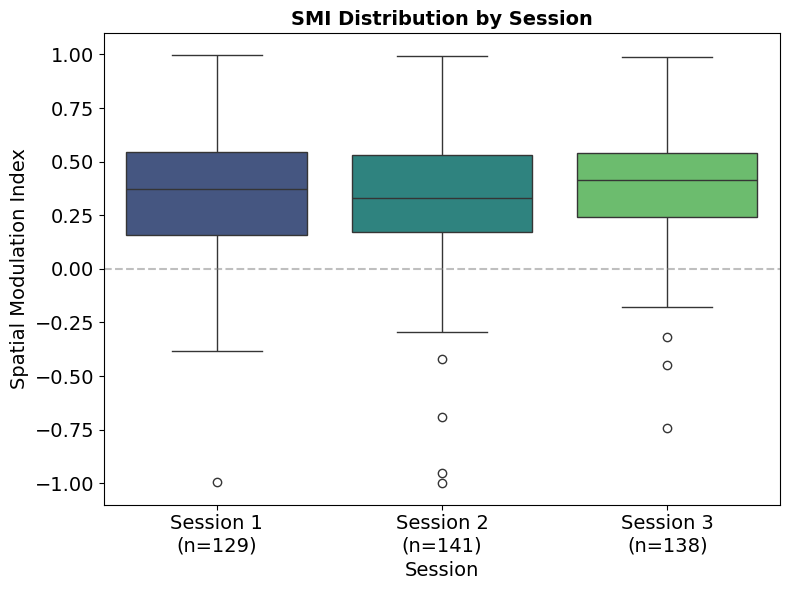

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Use the same data arrays from your previous script
# (day1_l23, day2_l23, day3_l23 should already be defined and flattened)

def create_boxplot_dataframe():
    """Create a long-format dataframe for the box plot"""
    data = []
    
    # Add data from all three sessions
    for val in day1_l23: data.append({'SMI': val, 'Session': 1})
    for val in day2_l23: data.append({'SMI': val, 'Session': 2})
    for val in day3_l23: data.append({'SMI': val, 'Session': 3})
    
    return pd.DataFrame(data)

# Create the dataframe
df = create_boxplot_dataframe()

# Create a simple figure with just the box plot
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Session', y='SMI', palette='viridis')
plt.title('SMI Distribution by Session', fontsize=14, fontweight='bold')
plt.ylabel('Spatial Modulation Index')
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)

# Add sample sizes to x-axis labels
session_data = {1: day1_l23, 2: day2_l23, 3: day3_l23}
session_ns = [len(session_data[i]) for i in range(1, 4)]
plt.xticks([0, 1, 2], [f'Session {i}\n(n={n})' for i, n in enumerate(session_ns, 1)])

plt.tight_layout()
plt.show()